# Analysis of Vehicle Characteristics and Fuel Efficiency

## Nely de Almeida Pedrosa

## Part 1: Selecting a Dataset

ISLP is the Python companion to *An Introduction to Statistical Learning*. It includes several pedagogically curated datasets across domains (marketing, finance, health, etc.).

Skim the ISLP documentation: [https://islp.readthedocs.io/en/latest/index.html](https://islp.readthedocs.io/en/latest/index.html).  Open the **“Datasets used in ISLP”** page and browse the available options.

The dataset I have chosen for this project is the Auto dataset from the ISLP library.

These variables help analyze how different car characteristics affect fuel efficiency

This dataset contains information about 392 automobiles, including their fuel efficiency, engine characteristics, and weight. Each observation represents a specific car model, and the dataset is useful for understanding the factors that influence fuel consumption.

The main features of this dataset include:

- mpg: fuel efficiency (miles per gallon)
- cylinders: number of cylinders in the engine
- displacement: engine size (cubic inches)
- horsepower: engine power
- weight: weight of the car
- acceleration: time to accelerate from 0 to 60 mph
- year: model year
- origin: country of origin

These variables allow us to analyze how different car characteristics affect fuel efficiency.

## Part 2: Loading Data from a Library

Install the necessary libraries:

In [ ]:
!pip install ISLP beautifulsoup4 pandas

In [2]:
import pandas as pd
from ISLP import load_data

# Load dataset
auto = load_data("Auto")

In [3]:
auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


In [4]:
auto.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, chevrolet chevelle malibu to chevy s-10
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
dtypes: float64(3), int64(5)
memory usage: 27.6+ KB


In [5]:
auto.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [6]:
auto['mpg'].value_counts().head()

mpg
13.0    20
14.0    19
18.0    17
15.0    16
26.0    14
Name: count, dtype: int64

In [7]:
auto['cylinders'].value_counts()

cylinders
4    199
8    103
6     83
3      4
5      3
Name: count, dtype: int64

This dataset contains information about different car models, including fuel efficiency, engine characteristics, and weight.

From the initial exploration, it is possible to observe that fuel efficiency (mpg) varies significantly across vehicles. Cars with more cylinders and higher horsepower tend to have lower fuel efficiency, while lighter cars generally achieve higher miles per gallon.

Another key observation is that most vehicles have between 4 and 8 cylinders, indicating a concentration in these categories. There is also noticeable variation in horsepower and weight, suggesting differences in vehicle performance and design.

Overall, the dataset appears clean, with no major missing values, making it suitable for further analysis.

A key question that can be explored using this dataset is:

How do engine characteristics such as horsepower, weight, and number of cylinders affect fuel efficiency (mpg)?

This question is relevant because understanding these relationships can help explain what factors contribute to better fuel economy, which is important for both consumers and manufacturers.

## Part 3: Scraping Data from Wikipedia

The Wikipedia page I have chosen is:
https://en.wikipedia.org/wiki/Fuel_economy_in_automobiles

Date accessed: April 27, 2026.

In [9]:
import requests
import pandas as pd

url = "https://en.wikipedia.org/wiki/Fuel_economy_in_automobiles"

headers = {"User-Agent": "Mozilla/5.0"}

response = requests.get(url, headers=headers)

tables = pd.read_html(response.text)

print(len(tables))

14


/tmp/ipykernel_1041/3463681867.py:10: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


In [13]:
df = tables[1].copy()

df.columns = [
    "weight_category",
    "number_of_vehicles",
    "percentage",
    "avg_miles_per_truck",
    "fuel_economy_mpg",
    "fuel_use_percentage"
]

df = df[df["weight_category"] != "Total"]

df["percentage"] = df["percentage"].str.replace('%', '').astype(float)
df["fuel_use_percentage"] = df["fuel_use_percentage"].str.replace('%', '').astype(float)

df.head()

,weight_category,number_of_vehicles,percentage,avg_miles_per_truck,fuel_economy_mpg,fuel_use_percentage
0,"6,000 lbs and less",51941389,61.0,11882,17.6,42.7
1,"6,001 – 10,000 lbs",28041234,32.9,12684,14.3,30.5
2,Light truck subtotal,79982623,93.9,12163,16.2,73.2
3,"10,001 – 14,000 lbs",691342,0.8,14094,10.5,1.1
4,"14,001 – 16,000 lbs",290980,0.3,15441,8.5,0.5


In [14]:
df


,weight_category,number_of_vehicles,percentage,avg_miles_per_truck,fuel_economy_mpg,fuel_use_percentage
0,"6,000 lbs and less",51941389,61.0,11882,17.6,42.7
1,"6,001 – 10,000 lbs",28041234,32.9,12684,14.3,30.5
2,Light truck subtotal,79982623,93.9,12163,16.2,73.2
3,"10,001 – 14,000 lbs",691342,0.8,14094,10.5,1.1
4,"14,001 – 16,000 lbs",290980,0.3,15441,8.5,0.5
5,"16,001 – 19,500 lbs",166472,0.2,11645,7.9,0.3
6,"19,501 – 26,000 lbs",1709574,2.0,12671,7.0,3.2
7,Medium truck subtotal,2858368,3.4,13237,8.0,5.2
8,"26,001 – 33,000 lbs",179790,0.2,30708,6.4,0.9
9,"33,001 lbs and up",2153996,2.5,45739,5.7,20.7


The data scraped from Wikipedia provides information about fuel economy across different categories of trucks based on their weight.

Although this dataset focuses on trucks and the ISLP Auto dataset focuses on passenger cars, both datasets relate to fuel efficiency and vehicle characteristics. The comparison is useful because it highlights how fuel consumption varies not only within cars, but also across different types of vehicles.

This complementary data provides a broader understanding of fuel economy, showing that heavier vehicles (such as trucks) tend to have lower fuel efficiency compared to lighter vehicles. This pattern is consistent with the trends observed in the Auto dataset.

## Part 4: Visualizing and Analyzing the Data

### Visualization 1

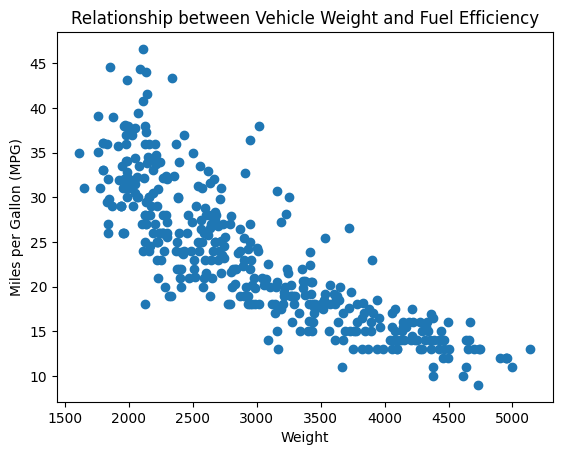

In [16]:
import matplotlib.pyplot as plt

plt.scatter(auto["weight"], auto["mpg"])
plt.xlabel("Weight")
plt.ylabel("Miles per Gallon (MPG)")
plt.title("Relationship between Vehicle Weight and Fuel Efficiency")
plt.show()

This scatter plot illustrates the relationship between vehicle weight and fuel efficiency (mpg). 

There is a clear negative relationship: as vehicle weight increases, fuel efficiency tends to decrease. Heavier cars consume more fuel, resulting in lower miles per gallon.

This suggests that weight is a key factor influencing fuel consumption and efficiency.

### Visualization 2

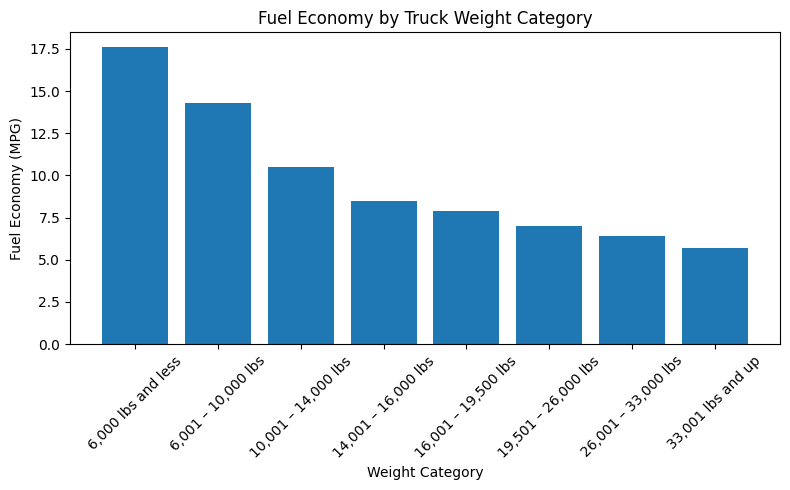

In [19]:
df_simple = df[~df["weight_category"].str.contains("subtotal")]

plt.figure(figsize=(8,5))
plt.bar(df_simple["weight_category"], df_simple["fuel_economy_mpg"])

plt.xticks(rotation=45)
plt.xlabel("Weight Category")
plt.ylabel("Fuel Economy (MPG)")
plt.title("Fuel Economy by Truck Weight Category")
plt.tight_layout()
plt.show()

This bar chart shows fuel economy (mpg) across different truck weight categories.

There is a clear decreasing trend: as truck weight increases, fuel efficiency declines. Lighter trucks have higher mpg values, while heavier trucks exhibit significantly lower fuel efficiency.

This pattern is consistent with the results observed in the Auto dataset, reinforcing the idea that vehicle weight negatively impacts fuel efficiency.

By comparing both datasets, it becomes evident that this relationship holds across different types of vehicles, including both passenger cars and trucks.

### Visualization 3

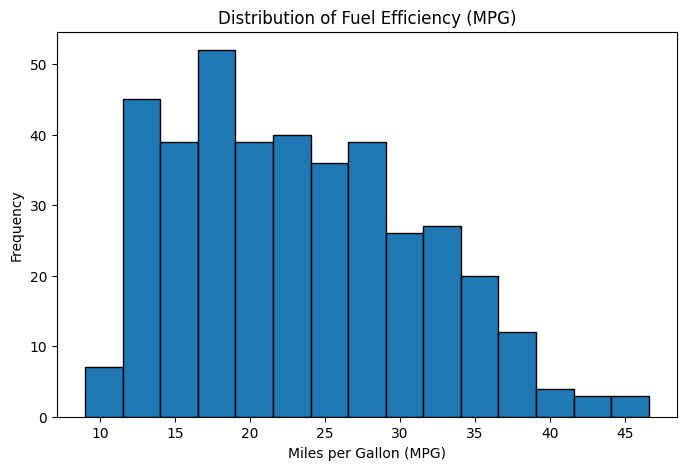

In [21]:
plt.figure(figsize=(8,5))

plt.hist(auto["mpg"], bins=15, edgecolor="black")

plt.xlabel("Miles per Gallon (MPG)")
plt.ylabel("Frequency")
plt.title("Distribution of Fuel Efficiency (MPG)")

plt.show()

This histogram shows the distribution of fuel efficiency (mpg) across the vehicles in the dataset.

Most vehicles are concentrated between approximately 15 and 30 mpg, indicating that moderate fuel efficiency is the most common.  There are fewer vehicles with very high mpg values, as well as fewer with very low fuel efficiency.

The distribution indicates that extremely high or low fuel efficiency values are less common, while most vehicles fall within a moderate range.

This visualization complements the previous analyses by showing how fuel efficiency values are distributed, helping to better understand the overall pattern observed in the dataset.

## Part 5: Executive Summary

This project aimed to investigate how engine characteristics such as weight, horsepower, and number of cylinders affect fuel efficiency (mpg).

Based on the visualizations, there is a clear negative relationship between vehicle weight and fuel efficiency. The scatter plot from the Auto dataset shows that as vehicle weight increases, mpg decreases significantly. Heavier cars tend to consume more fuel, while lighter vehicles achieve higher fuel efficiency. In addition, vehicles with more cylinders and higher horsepower also tend to have lower mpg, reinforcing the idea that engine size and power influence fuel consumption.

This pattern is further supported by the bar chart using the Wikipedia dataset, which shows that heavier trucks also have lower fuel economy compared to lighter trucks. Together, these results suggest that vehicle weight is a key factor influencing fuel consumption across different types of veicles, including both passenger cars and trucks.

However, there are some limitations to this analysis. The Auto dataset represents older car models and may not reflect modern vehicle technologies. The Wikipedia data focuses on aggregated truck categories rather than individual observations, which limits detailed comparisons. Additionally, this analysis identifies relationships but does not prove causation.

As a next step, a regression model could be applied to quantify the impact of variables such as weight, horsepower, and cylinders on fuel efficiency. This would provide a more precise and data-driven understanding of how these factors influence fuel consumption.

## Part 6: References

James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). An introduction to statistical learning: With applications in Python. Springer. https://www.statlearning.com/

Wikipedia contributors. (2026). Fuel economy in automobiles. Wikipedia. Retrieved April 27, 2026, from https://en.wikipedia.org/wiki/Fuel_economy_in_automobiles

McKinney, W. (2022). Python for data analysis (3rd ed.). O’Reilly Media.

Pandas Development Team. (2024). pandas documentation. https://pandas.pydata.org/

OpenAI. (2026). ChatGPT (April 27 version) [Large language model]. https://chat.openai.com/

Note: Code assistance was supported by ChatGPT.